In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
# Перевод столбца в формат даты
df['Дата'] = pd.to_datetime(df['Дата'])

# Проверка результата
print(df['Дата'].dtype)

datetime64[ns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head(3))

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193


Нарисуйте график продаж у `grouped_df`

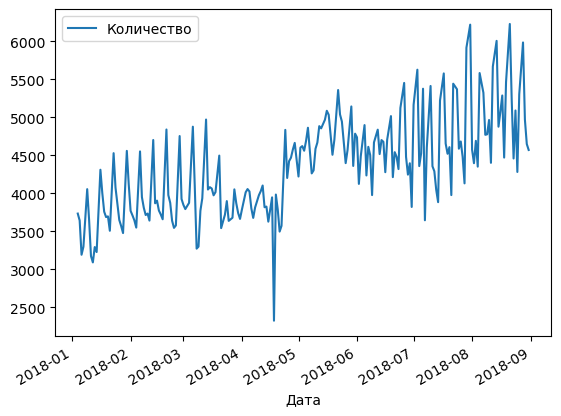

In [7]:
grouped_df.plot(x="Дата", y="Количество")
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

**Анализ графика:**

График показвает что продажи уверенно растут с января по сентябрь. Если в начале года они были где-то около 3 500 – 4 000, то к концу лета поднялись до 5 000 – 5 500.
График имеет пилообразный вид. Это регулярные спады и подъемы — это, скорее всего, недельная логика (например, в будни дни покупают много, в выходные мало, или наоборот). При этом к концу лета размах стал еще сильнее.
В конце апреля -начале мая виден самый глубокий провал (скачок вниз почти до 2 200). Это может быть связано с майскими праздниками, когда никто не работал.
Самые большие продажи были в августе и сентябре -там график несколько раз пробивал отметку в 6 000 штук.
Судя по графику, у бизнеса объемы продаж растут, но праздничные дни сильно бьют по показателям.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
Q1 = df['Количество'].quantile(0.25)         
Q3 = df['Количество'].quantile(0.75)
IQR = Q3 - Q1                                
upper_b = Q3 + 1.5 * IQR                         
out = df[df['Количество'] > upper_b]             
max_out = out.loc[[out['Количество'].idxmax()]]  

max_out

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [9]:
summer_month_df = df[df['Склад'] == 3].copy()
summer_month_df = summer_month_df[summer_month_df['Дата'].dt.month.isin([6, 7, 8])]

wednesday_df = summer_month_df[summer_month_df['Дата'].dt.weekday == 2]

top_product_sales = wednesday_df.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product_sales = top_product_sales.sort_values(by='Количество', ascending=False)

top_product_sales.head(1)

,Номенклатура,Количество
1,product_1,2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [10]:
weather_df = pd.read_csv('weather.csv', sep=';')

weather_df.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.12.2018 23:00,"-18,4","744,8","780,4","0,5",87.0,"Ветер, дующий с юго-запада",1,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,"-20,0","0,6",12.0,NaN,NaN,NaN,NaN
1,31.12.2018 20:00,"-17,2","744,3","779,6","0,6",86.0,"Ветер, дующий с юга",1,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,"-19,0","0,6",12.0,NaN,NaN,NaN,NaN
2,31.12.2018 17:00,"-14,8","743,7","778,6","0,8",84.0,"Ветер, дующий с западо-юго-запада",1,NaN,NaN,...,NaN,NaN,NaN,"-16,9",NaN,NaN,NaN,NaN,NaN,NaN
3,31.12.2018 14:00,"-11,2","742,9","777,3","0,5",76.0,"Ветер, дующий с западо-юго-запада",2,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистые нитевидные, иногда когтевидные, не ра...","10,0","-14,6",NaN,NaN,NaN,NaN,NaN,NaN
4,31.12.2018 11:00,"-12,7","742,4","777,1","0,5",79.0,"Ветер, дующий с юго-юго-востока",2,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...","4,0","-15,6","0,3",12.0,NaN,NaN,NaN,NaN


In [11]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Местное время в Астане  2918 non-null   object 
 1   T                       2918 non-null   object 
 2   Po                      2918 non-null   object 
 3   P                       2918 non-null   object 
 4   Pa                      2913 non-null   object 
 5   U                       2916 non-null   float64
 6   DD                      2918 non-null   object 
 7   Ff                      2918 non-null   int64  
 8   ff10                    19 non-null     float64
 9   ff3                     67 non-null     float64
 10  N                       2916 non-null   object 
 11  WW                      2918 non-null   object 
 12  W1                      1099 non-null   object 
 13  W2                      1099 non-null   object 
 14  Tn                      363 non-null    

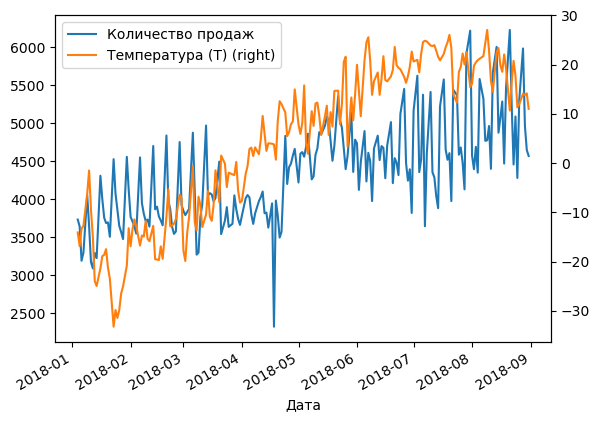

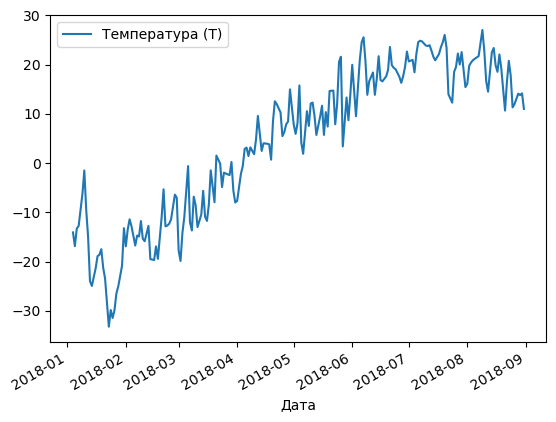

In [12]:
weather_df['Дата'] = pd.to_datetime(weather_df['Местное время в Астане'], dayfirst=True).dt.normalize()

weather_df['T'] = weather_df['T'].astype(str).str.replace(',', '.')
weather_df['T'] = pd.to_numeric(weather_df['T'])

daily_temp = weather_df.groupby('Дата')['T'].mean().reset_index()

final_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')

plot_df = final_df.rename(columns={'Количество': 'Количество продаж', 'T': 'Температура (Т)'})
plot_df.plot(x='Дата', y=['Количество продаж', 'Температура (Т)'], secondary_y='Температура (Т)')
plot_df.plot(x='Дата', y='Температура (Т)')

plt.show()

**Вывод:** Согласно совмещенному графику видно,что обе линии идут вверх почти одинаково. Что означает, что чисто визуально бизнес имеет сезонность - когда погода теплеет, тоесть летом, чем в морозы, спрос на товары уведичиваются и продажи растут.